In [43]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import json

In [44]:
curr_dir=os.getcwd()
grandparent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir,os.pardir))
pardir=os.path.abspath(os.path.join(curr_dir, os.pardir))
print(pardir)
sys.path.append(os.path.join(pardir))
print(sys.path)

c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\seizure_detection
['c:\\nrn\\lib\\python', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\python39.zip', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\DLLs', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples', '', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32\\lib', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\Pythonwin', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\seizure_detection', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\seizure_detection\\up_dn_spikes\\..', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\setuptools\\_vendor', 'c:\\Us

In [46]:
bandpass=[1,70]
downsampled_fs = 1000 # Downsampled frequency
fraction=(0,0.8)
min_spikes=3
min_threshold=0.5
adapt=20

In [47]:
WINDOW_SIZE = int(200)   # in timesteps (ms) - The size of the window to slice the input data

# unit: timesteps (ms) - The number of steps that 2 consecutive windows must overlap to not lose any relevant CBs

# std, mean = ripples_std(parent) # 61 ms # in seconds
# INTERSECT_WINDOW_LEN=int((std+mean)*1000) # in timesteps (ms) - The size of the intersection window to slice the input data
INTERSECT_WINDOW_LEN=100 # in timesteps (ms) - The size of the intersection window to slice the input data

# unit: timesteps (ms) - The number of steps that the window must shift to get the next window
WINDOW_SHIFT = int(WINDOW_SIZE - INTERSECT_WINDOW_LEN)

MARGINS=(20,20)

## Extract Windows
Extract UP/DN spike Windows


In [48]:
load=False
data_dir=os.path.join(curr_dir,"up_dn_data")
# Only run this block if first time
from make_up_dn_iis import *
if 'windowed_input_dataa' not in locals():
    if load:
        windowed_path=os.path.join(curr_dir,"windowed_data")
        windowed_input_data = np.load(os.path.join(windowed_path,"windowed_input_data.npy"))
        windowed_gt = np.load(os.path.join(windowed_path,"windowed_gt.npy"))
        filtered_windows=np.load(os.path.join(windowed_path,"filtered_windows.npy"))
    else:
        windowed_input_data, windowed_gt, filtered_windows, ripple_ids=make_windows([0,1], WINDOW_SIZE,WINDOW_SHIFT,MARGINS,min_spikes=1,fraction=(0,1),min_threshold=min_threshold,adapt_threshold=adapt)
    print("windowed_input_data already loaded")

data shape:  (1700000, 8, 2)
iiss shape:  (252,)
[WARNING] GT event 203714 starts before the window [203700:203900]. Skipping...
[WARNING] GT event 209913 starts before the window [209900:210100]. Skipping...
[WARNING] GT event 210019 starts before the window [210000:210200]. Skipping...
[WARNING] GT event 210101 starts before the window [210100:210300]. Skipping...
[WARNING] GT event 210308 starts before the window [210300:210500]. Skipping...
[WARNING] GT event 210401 starts before the window [210400:210600]. Skipping...
[WARNING] GT event 210516 starts before the window [210500:210700]. Skipping...
[WARNING] GT event 210717 starts before the window [210700:210900]. Skipping...
[WARNING] GT event 211007 starts before the window [211000:211200]. Skipping...
[WARNING] GT event 213209 starts before the window [213200:213400]. Skipping...
[WARNING] GT event 215018 starts before the window [215000:215200]. Skipping...
[WARNING] GT event 215407 starts before the window [215400:215600]. Ski

In [49]:
up_spikes_per_window = np.sum(windowed_input_data[:, :, 0], axis=1)    # Sum along time axis
down_spikes_per_window = np.sum(windowed_input_data[:, :, 1], axis=1)  # Sum along time axis
print("Up Spikes Total:",np.sum(up_spikes_per_window))
print("Down Spikes Total:",np.sum(down_spikes_per_window))
# print(config)

Up Spikes Total: 2160430.0
Down Spikes Total: 2105265.0


In [50]:
# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(windowed_gt, return_counts=True)}")
GT_HFO_MASK = windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / windowed_gt.shape[0] * 100:.2f}%")

# Save to config.json
# config["num_hfo_windows"] = num_hfo_windows
# config["num_windows"] = windowed_gt.shape[0]
# config["percentage_hfo_windows"] = num_hfo_windows / windowed_gt.shape[0] * 100


Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 160., 161., 162., 163., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 179.], dtype=float32), array([802200,    291,    239,    337,    296,    244,    222,    326,    227,    213,    209,
          234,    249,    292,    316,    236,    241,    312,    208,     94, ...,     68,     62,
           53,     83,    127,    132,     87,     85,    145,     39,     76,     91,     63,
           75,    113,     44,    105,     86,    107,     85], dtype=int64))
Number of windows with an HFO: 21852
Percentage of windows with an HFO: 2.65%


In [51]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
sorted_indices = np.argsort(
    -(np.sum(windowed_input_data[:, :, 0], axis=1) + np.sum(windowed_input_data[:, :, 1], axis=1)), 
)
sorted_spikes = windowed_input_data[sorted_indices]
sorted_gt= windowed_gt[sorted_indices]
sorted_filtered_windows=filtered_windows[sorted_indices]
sorted_ripples=ripple_ids[sorted_indices]
sorted_up_spikes_per_window = np.sum(sorted_spikes[:, :, 0], axis=1)    # Sum along time axis
sorted_down_spikes_per_window = np.sum(sorted_spikes[:, :, 1], axis=1)  # Sum along time axis
print(f"sorted_indices: {sorted_indices}")
print(f"Sorted_data: {sorted_spikes.shape} | Sorted_gt: {sorted_gt.shape}| Sorted_filtered_windows: {sorted_filtered_windows.shape}")
print(f"Sorted_gt preview: {sorted_gt[:10]}")
print(f"GT first window: {sorted_gt[0]} | GT last window: {sorted_gt[-1]}")
total_spikes_per_window = sorted_up_spikes_per_window + sorted_down_spikes_per_window
print(f"Total Spikes per window: {total_spikes_per_window[:10]} | {total_spikes_per_window[-10:]}")

sorted_indices: [578652 578630 781196 578653 578631 315289 781193 538898 315290 784709 819174 784751 315288 784718
 819211 784707 784734 784721 819169 781191 ... 436309 723591 307086 500911 152041 387348 738649
 500906 500905 500845 632949 738650 436298 152069 436304 500884 436305 387360 500891 474990]
Sorted_data: (824052, 200, 2) | Sorted_gt: (824052,)| Sorted_filtered_windows: (824052, 200)
Sorted_gt preview: [-1. 90. 23. -1. 24. -1. 73. -1. -1. 27.]
GT first window: -1.0 | GT last window: -1.0
Total Spikes per window: [153. 137. 136. 134. 132. 128. 125. 125. 124. 123.] | [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [52]:
indices=np.arange(0,1000)
sorted_gt_distribution=sorted_gt[indices]
print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")
print(f"Total Spikes per window: {total_spikes_per_window[indices]}")


Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 107., 108., 109., 110., 111., 117., 120., 123., 132.,
       146., 147., 150., 151., 157., 158., 166., 172., 175., 176., 178.], dtype=float32), array([224,  19,  18,  33,  30,   7,  13,  24,  18,  12,  16,  22,   4,  15,   6,  12,  10,  28,
        32,   7, ...,  12,   6,  14,   1,   3,   4,  13,   3,   4,   1,   2,   6,   6,   8,   5,
         1,   2,   1,  11,   6], dtype=int64))
Total Spikes per window: [153. 137. 136. 134. 132. 128. 125. 125. 124. 123. 123. 120. 120. 119. 119. 118. 117. 117. 117.
 116. ...  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.  78.
  78.  78.]


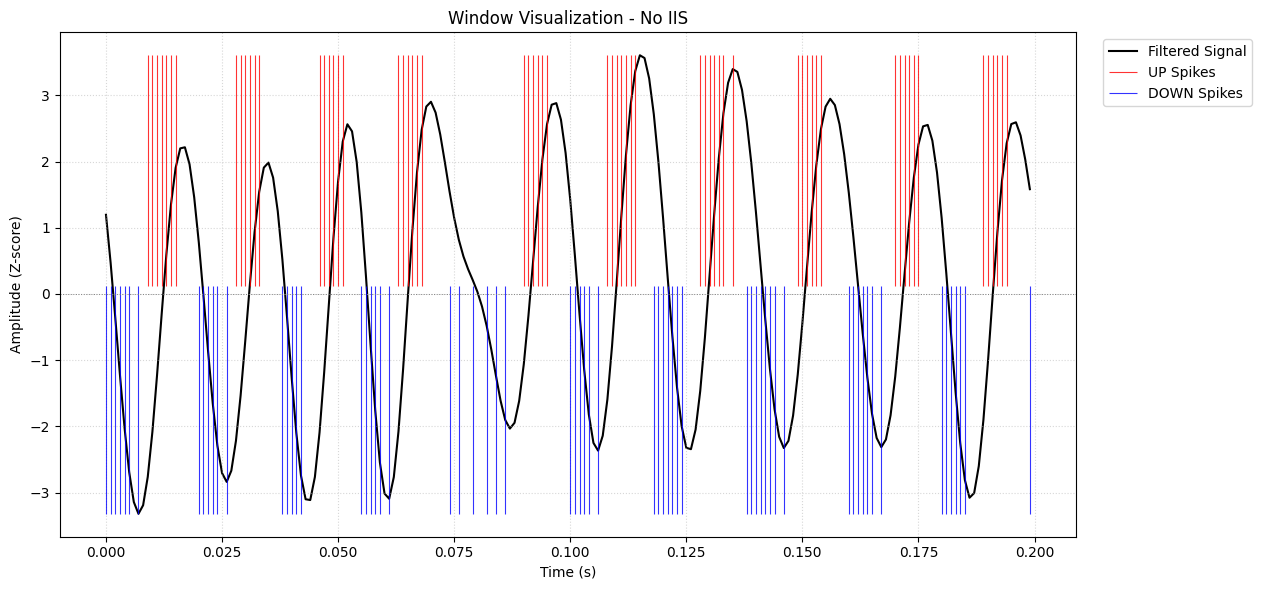

In [53]:
window=5
plot_spikes=sorted_spikes[window,:,:]
plot_gt=sorted_gt[window]
plot_filtered_window=sorted_filtered_windows[window,:]
iis_window_plot(plot_filtered_window, plot_spikes, plot_gt, downsampled_fs=downsampled_fs, detection_margins=MARGINS)# up_spikes_window = np.sum(plot_spikes[:, 0])    # Sum along time axis

In [54]:
is_hfo = windowed_gt >= 0
hfo_windows = windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2) 

In [55]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
og_total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
og_total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts
average_total_counts= (np.sum(og_total_hfo_counts)+np.sum(og_total_nonhfo_counts))/len(windowed_input_data)

# Print the average counts
average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(og_total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(og_total_nonhfo_counts)
median_hfo_counts=np.median(og_total_hfo_counts)
median_nonhfo_counts=np.median(og_total_nonhfo_counts)
print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")
print(f"Median HFO Counts: {median_hfo_counts}")
print(f"Median Non-HFO Counts: {median_nonhfo_counts}")

# # Add to config dictionary
# config.update({
#     "average_hfo_up_counts": average_hfo_up_counts,
#     "average_hfo_down_counts": average_hfo_down_counts,
#     "average_total_hfo_counts": average_total_hfo_counts,
#     "average_nonhfo_up_counts": average_nonhfo_up_counts,
#     "average_nonhfo_down_counts": average_nonhfo_down_counts,
#     "average_total_nonhfo_counts": average_total_nonhfo_counts,
#     "average_total_counts": average_total_counts,
#     "median_hfo_counts": median_hfo_counts,
#     "median_nonhfo_counts": median_nonhfo_counts,
# })


Average HFO Up Counts: 14.349990847519678
Average HFO Down Counts: 13.065302947098663
Average Total HFO Counts: 27.415293794618343
Average Non-HFO Up Counts: 2.302236350037397
Average Non-HFO Down Counts: 2.2684642233856893
Average Total Non-HFO Counts: 4.570700573423086
Average Total Counts: 5.1764876488376945
Median HFO Counts: 21.0
Median Non-HFO Counts: 4.0


In [56]:
def get_isi(spike_train):
    times_up = np.where(spike_train[:,0])[0]  # spike times (e.g., indices)
    times_down = np.where(spike_train[:,0])[0]  # spike times (e.g., indices)
    times_total= np.concatenate((times_up, times_down))
    times_total.sort()  # sort the spike times
    if len(times_total) < 2:
        return np.array([])  # no ISI to compute
    return np.diff(times_total)

# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])


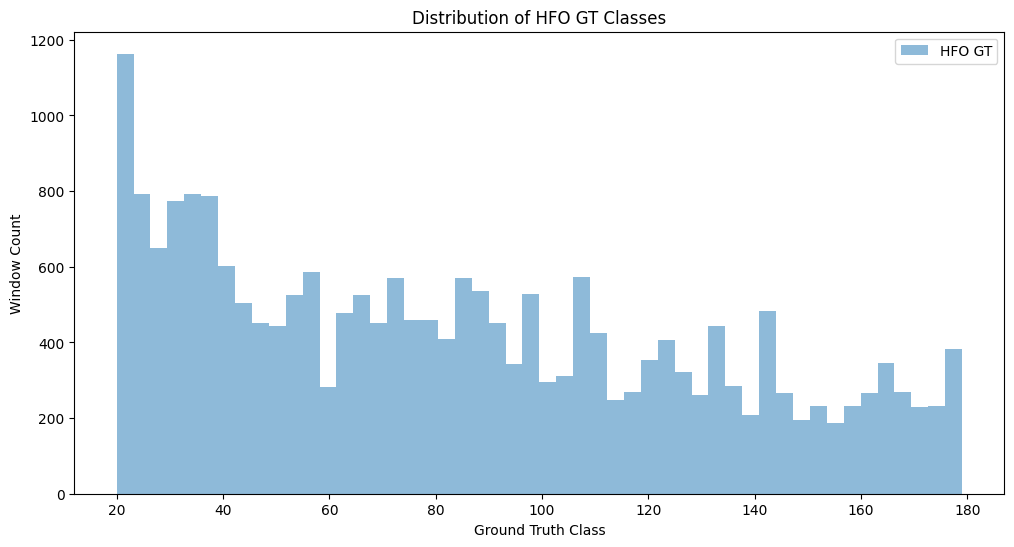

In [57]:
plt.subplots(figsize=(12, 6))
plt.hist(windowed_gt_hfo, bins=50, alpha=0.5, label='HFO GT')
plt.legend()
plt.title('Distribution of HFO GT Classes')
plt.xlabel('Ground Truth Class')
plt.ylabel('Window Count')
plt.show()

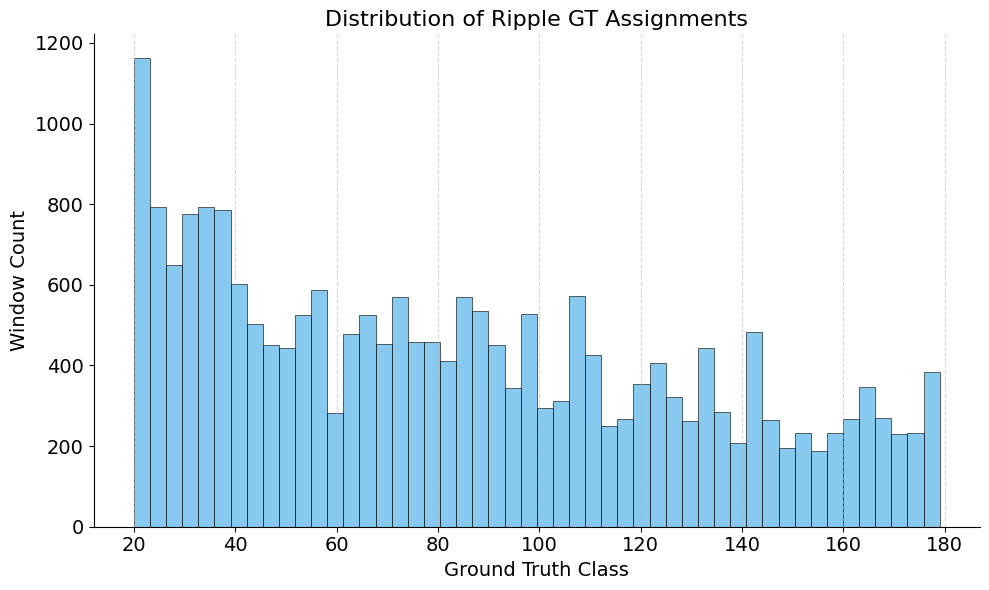

In [58]:
def plot_hfo_gt_distribution(windowed_gt_hfo):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(windowed_gt_hfo, bins=50, orientation='vertical', alpha=0.7, 
            color="#56B4E9", edgecolor='black', linewidth=0.6)

    # Labels and title
    ax.set_ylabel("Window Count", fontsize=14)
    ax.set_xlabel("Ground Truth Class", fontsize=14)
    ax.set_title("Distribution of Ripple GT Assignments", fontsize=16)

    # Style
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=14)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig, ax
fig, ax = plot_hfo_gt_distribution(windowed_gt_hfo)
path_figs=os.path.join(curr_dir,"dataset_up_down","figures")
file= os.path.join(path_figs,"hfo_gt_distribution.png")
# fig.savefig(file, dpi=300)

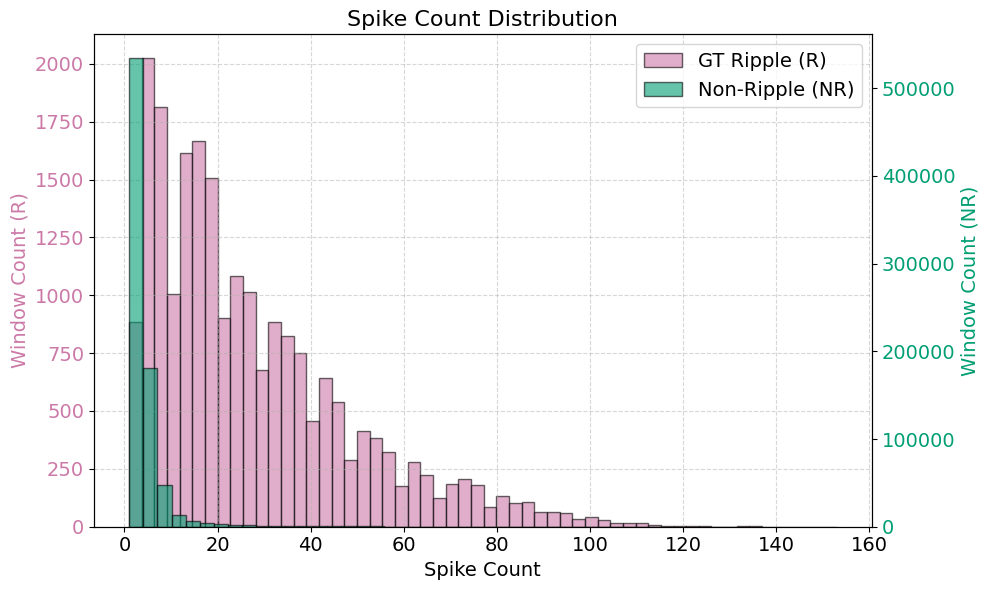

In [59]:
import matplotlib.pyplot as plt

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6 ))

# Plot first histogram (HFO)
color1 = "#CC79A7"  # Orange
counts1, bins1, patches1 = ax1.hist(og_total_hfo_counts, bins=50, alpha=0.6,
                                    label="HFO Up Spikes", color=color1, edgecolor='black')
ax1.set_xlabel("Spike Count", fontsize=14)
ax1.set_ylabel("Window Count (R)", fontsize=14, color=color1)
ax1.tick_params(axis='y', labelcolor=color1,labelsize=14)

# Create second y-axis
ax2 = ax1.twinx()
color2 = "#009E73"  # Blue
counts2, bins2, patches2 = ax2.hist(og_total_nonhfo_counts, bins=50, alpha=0.6,
                                    label="Non-HFO Up Spikes", color=color2, edgecolor='black')
ax2.set_ylabel("Window Count (NR)", fontsize=14, color=color2)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=14)
ax1.tick_params(axis='x', labelsize=14) 
# Title and aesthetics
plt.title("Spike Count Distribution", fontsize=16)
fig.tight_layout()

# Legends (merged manually since twin axes can't auto-combine legends)
lines = [patches1[0], patches2[0]]
labels = ["GT Ripple (R)", "Non-Ripple (NR)"]
ax1.legend(lines, labels, loc="upper right", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
plt.show()

# file= os.path.join(path_figs,"spike_count_distribution.png")
# fig.savefig(file, dpi=300)

In [60]:
hist_ripples = np.histogram(og_total_hfo_counts, bins=100)
hist_nonripples = np.histogram(og_total_nonhfo_counts, bins=100)

config={}
config["n_bins"]= len(hist_ripples[0])
config=evaluate_histogram(hist_ripples,hist_nonripples,config)


Bhattacharyya Distance: 0.6123
KL Divergence: 2.5757
Earth Mover’s Distance: 17.1501
Chi-Square Statistic: 118101597.9691, p-value: 0.0000


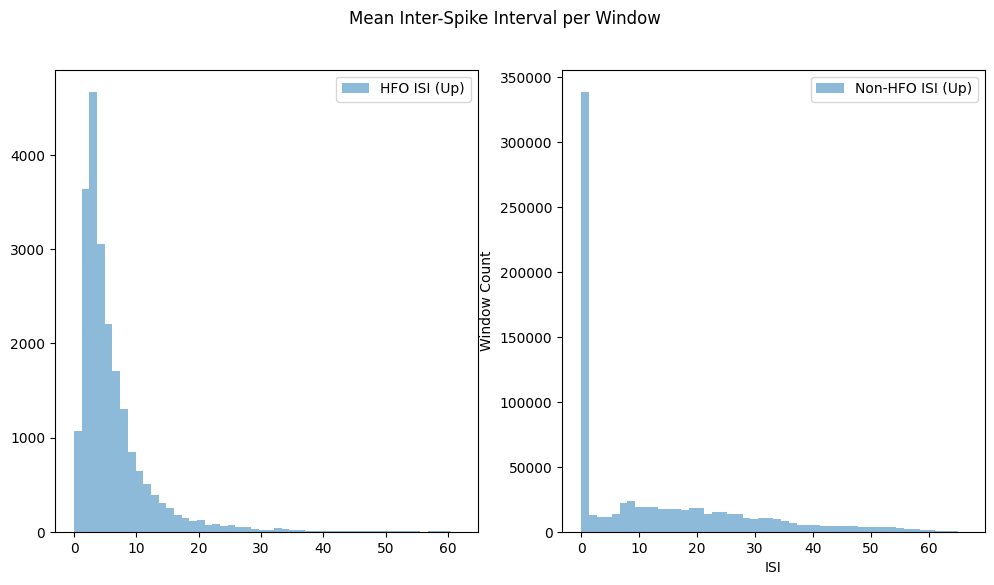

In [61]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(hfo_up_isi_mean, bins=50, alpha=0.5, label='HFO ISI (Up)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(nonhfo_up_isi_mean, bins=50, alpha=0.5, label='Non-HFO ISI (Up)')
plt.legend()
plt.suptitle('Mean Inter-Spike Interval per Window')
plt.xlabel('ISI')
plt.ylabel('Window Count')
plt.show()

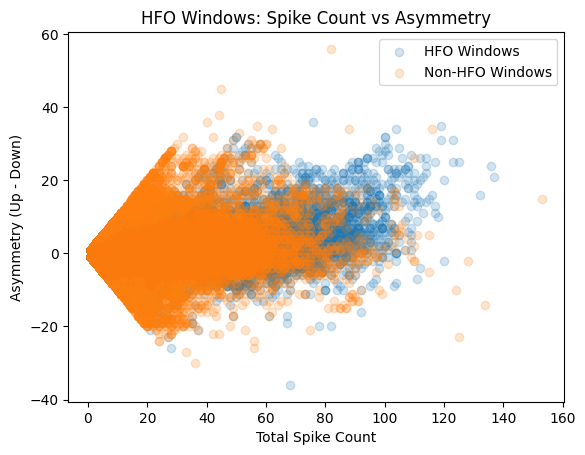

In [62]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(og_total_hfo_counts,asymmetry_hfos , alpha=0.2, label='HFO Windows')
plt.scatter(og_total_nonhfo_counts,asymmetry_nonhfos, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

c:\Users\NCN\miniconda3\envs\lava_snn_ripples\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


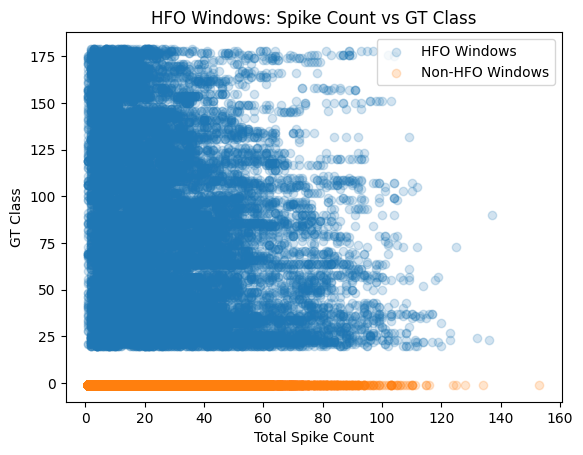

In [63]:
plt.scatter(og_total_hfo_counts,windowed_gt_hfo, alpha=0.2, label='HFO Windows')
plt.scatter(og_total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs GT Class')
plt.legend()
plt.show()
# print(config)

## Process Windows

In [21]:
p1_windowed_input_data,p1_windowed_gt,p1_ripple_ids=only_some_channels_per_ripple(windowed_input_data,windowed_gt,ripple_ids,3)


In [22]:
# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(p1_windowed_gt, return_counts=True)}")



GT_HFO_MASK = p1_windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / p1_windowed_gt.shape[0] * 100:.2f}%")



Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 159., 160., 161., 162., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 180.], dtype=float32), array([25641,    51,    34,    61,    74,    35,    29,    55,    42,    31,    22,    32,    42,
          70,    50,    18,    41,    59,    59,     7, ...,     3,     8,     1,     1,     4,
           8,     8,     3,     2,     1,     3,     1,     3,     5,     7,     2,     3,     3,
           5,     4], dtype=int64))
Number of windows with an HFO: 3287
Percentage of windows with an HFO: 11.36%


In [24]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
sorted_indices = np.argsort(
    -(np.sum(p1_windowed_input_data[:, :, 0], axis=1) + np.sum(p1_windowed_input_data[:, :, 1], axis=1)), 
)
sorted_spikes = p1_windowed_input_data[sorted_indices]
sorted_gt= p1_windowed_gt[sorted_indices]
sorted_ripples=p1_ripple_ids[sorted_indices]
sorted_up_spikes_per_window = np.sum(sorted_spikes[:, :, 0], axis=1)    # Sum along time axis
sorted_down_spikes_per_window = np.sum(sorted_spikes[:, :, 1], axis=1)  # Sum along time axis
print(f"sorted_indices: {sorted_indices}")
print(f"Sorted_data: {sorted_spikes.shape} | Sorted_gt: {sorted_gt.shape}")
print(f"Sorted_gt preview: {sorted_gt[:10]}")
print(f"GT first window: {sorted_gt[0]} | GT last window: {sorted_gt[-1]}")

sorted_indices: [27050 12156 27053 12155 12137 12157 12136 12138 10091 12124 10797 12154 27047 12142 27041 12135
 26276 12195 12158 12196 ... 21591 21589 21567 14168 14165 14164 14162 14161 14159 14153 21578
 21581 21583 14156 14155 21586 14154 21588 21580 13335]
Sorted_data: (28928, 200, 2) | Sorted_gt: (28928,)
Sorted_gt preview: [90. -1. 24. -1. -1. -1. -1. -1. -1. -1.]
GT first window: 90.0 | GT last window: -1.0


In [25]:
sorted_gt_distribution=sorted_gt[:1000]
print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")

Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  39., ..., 117., 118., 119., 120., 122., 123., 133., 136., 141.,
       145., 147., 149., 151., 154., 155., 165., 172., 173., 175., 180.], dtype=float32), array([200,  21,  19,  16,  35,  20,  13,  17,  27,   8,   5,  13,   6,  14,  20,   3,  17,  27,
        30,   2, ...,   3,   1,   3,   1,   1,   2,   2,   1,   2,   1,   1,   1,   1,   1,   1,
         1,   1,   4,   1,   1], dtype=int64))


In [32]:
is_hfo = p1_windowed_gt >= 0
hfo_windows = p1_windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = p1_windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = p1_windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = p1_windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2)

In [28]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts

average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(total_nonhfo_counts)
average_total_counts= (np.sum(total_hfo_counts)+np.sum(total_nonhfo_counts))/len(p1_windowed_input_data)

print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")

Average HFO Up Counts: 3.6953418482344103
Average HFO Down Counts: 3.6230277986476334
Average Total HFO Counts: 7.318369646882044
Average Non-HFO Up Counts: 1.4645294645294644
Average Non-HFO Down Counts: 1.3733863733863734
Average Total Non-HFO Counts: 2.837915837915838
Average Total Counts: 5.209243639380531


In [29]:
# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])


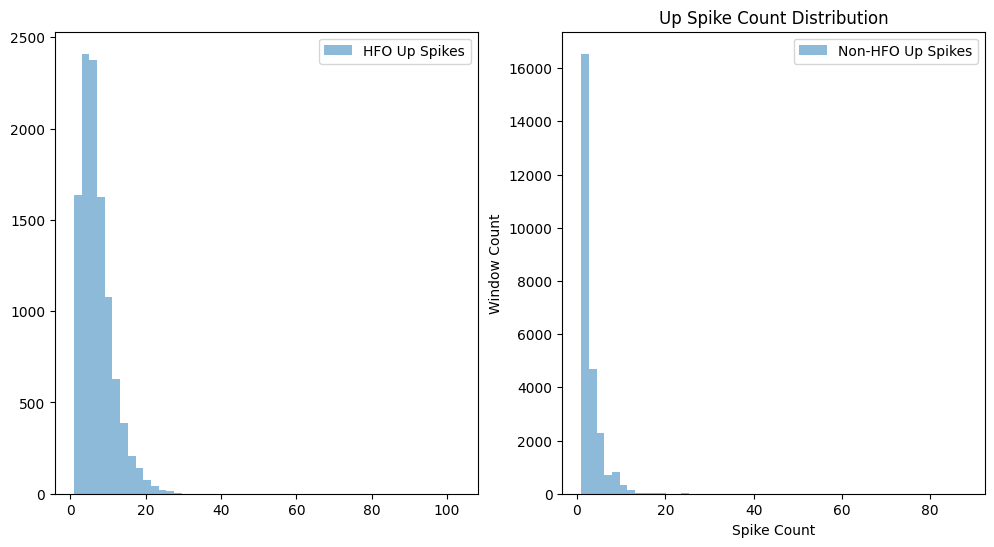

In [30]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(total_hfo_counts,bins=50, alpha=0.5, label='HFO Up Spikes')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Up Spikes')
plt.legend()
plt.title('Up Spike Count Distribution')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.show()

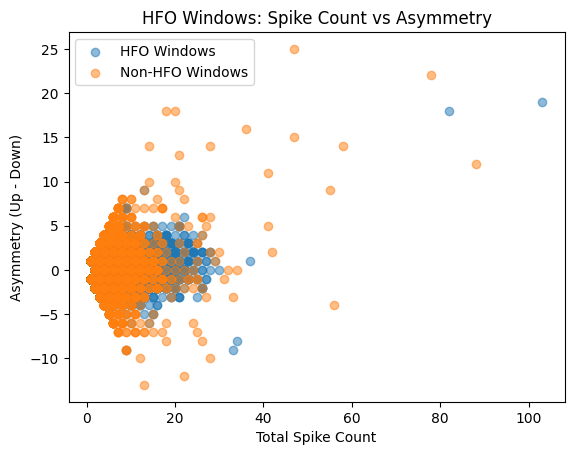

In [31]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(total_hfo_counts,asymmetry_hfos , alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,asymmetry_nonhfos, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

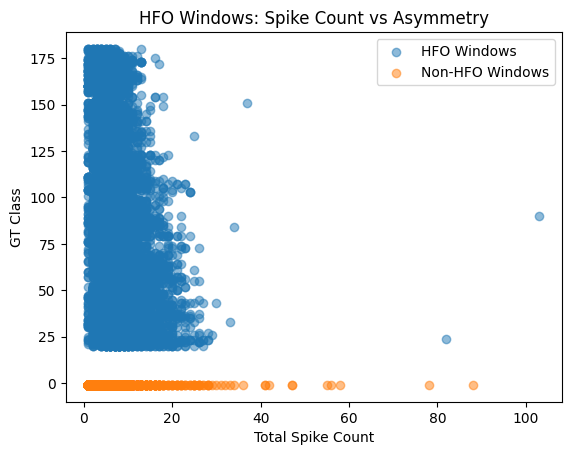

In [32]:
plt.scatter(total_hfo_counts,windowed_gt_hfo, alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()

## Process - Remove Windows above thresholds

In [ ]:
# print(average_total_hfo_counts)
# thresholds=[average_total_counts,average_total_hfo_counts*20]


nonhfo_threshold = np.percentile(og_total_nonhfo_counts, 90) 
hfo_activity_threshold = np.percentile(og_total_hfo_counts, 50) 
# thresholds = [nonhfo_threshold, hfo_activity_threshold]
thresholds=[1]

# thresholds=[100,50]
# p2_windowed_input_data,p2_windowed_gt,p2_ripple_ids=min_max_spike_threshold(p1_windowed_input_data,p1_windowed_gt,
#                                                                          p1_ripple_ids,MEAN_DETECTION_OFFSET,thresholds)

p2_windowed_input_data,p2_windowed_gt,p2_ripple_ids=min_max_spike_threshold_prob(windowed_input_data,windowed_gt,
                                                                         ripple_ids,thresholds,max_prob=1,multiplier=2,decay=3,drop_fn=drop_exponential)

False Positive Removed (Prob 0.41) - Spikes: 4.0
False Negative Removed (Prob 0.31) - Spikes: 8.0
False Negative Removed (Prob 0.31) - Spikes: 8.0
False Positive Removed (Prob 0.63) - Spikes: 3.0
False Negative Removed (Prob 0.52) - Spikes: 9.0
False Negative Removed (Prob 0.86) - Spikes: 14.0
False Negative Removed (Prob 0.74) - Spikes: 11.0
False Negative Removed (Prob 0.79) - Spikes: 12.0
False Negative Removed (Prob 0.52) - Spikes: 9.0
False Negative Removed (Prob 0.86) - Spikes: 14.0
False Negative Removed (Prob 0.52) - Spikes: 9.0
False Negative Removed (Prob 0.79) - Spikes: 12.0
False Negative Removed (Prob 0.52) - Spikes: 9.0
False Positive Removed (Prob 0.41) - Spikes: 4.0
False Positive Removed (Prob 0.75) - Spikes: 2.0
False Positive Removed (Prob 0.75) - Spikes: 2.0
False Positive Removed (Prob 0.75) - Spikes: 2.0
False Positive Removed (Prob 0.63) - Spikes: 3.0
False Positive Removed (Prob 0.63) - Spikes: 3.0
False Positive Removed (Prob 0.82) - Spikes: 1.0
False Positive 

In [26]:
# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(p2_windowed_gt, return_counts=True)}")



GT_HFO_MASK = p2_windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / p2_windowed_gt.shape[0] * 100:.2f}%")

Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 160., 161., 162., 163., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 179.], dtype=float32), array([168362,    202,    166,    255,    201,    161,    169,    244,    144,    157,    139,
          133,    141,    186,    181,    143,    137,    230,    156,     55, ...,     22,     33,
           35,     39,     74,     51,     35,     37,     53,     15,     62,     27,     19,
           30,     53,     18,     55,     43,     43,     45], dtype=int64))
Number of windows with an HFO: 13143
Percentage of windows with an HFO: 7.24%


In [27]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
sorted_indices = np.argsort(
    -(np.sum(p2_windowed_input_data[:, :, 0], axis=1) + np.sum(p2_windowed_input_data[:, :, 1], axis=1)), 
)
sorted_spikes = p2_windowed_input_data[sorted_indices]
sorted_gt= p2_windowed_gt[sorted_indices]
sorted_ripples=p2_ripple_ids[sorted_indices]
sorted_up_spikes_per_window = np.sum(sorted_spikes[:, :, 0], axis=1)    # Sum along time axis
sorted_down_spikes_per_window = np.sum(sorted_spikes[:, :, 1], axis=1)  # Sum along time axis
print(f"sorted_indices: {sorted_indices}")
print(f"Sorted_data: {sorted_spikes.shape} | Sorted_gt: {sorted_gt.shape}")
print(f"Sorted_gt preview: {sorted_gt[:10]}")
print(f"GT first window: {sorted_gt[0]} | GT last window: {sorted_gt[-1]}")

sorted_indices: [166848 158032 128522 163041 158031  44275 172198  44274 128521  44273  44272  44271  44270  44269
  44268  44267  44266  44265  44264  44263 ...  89080  89079  89076  89075  89074  89070  89067
  89066  89065  89064  89061  89060  89059  89043  89042  89040  89039  89037  89032 181504]
Sorted_data: (181505, 200, 2) | Sorted_gt: (181505,)
Sorted_gt preview: [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
GT first window: -1.0 | GT last window: -1.0


In [28]:
sorted_gt_distribution=sorted_gt[:1000]
sorted_ripple_distribution=sorted_ripples[:1000]

print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")
print(f"Sorted Ripple Distribution: {np.unique(sorted_ripple_distribution, return_counts=True)}")


Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ...,  95.,  96.,  98.,  99., 100., 103., 104., 106., 107.,
       110., 120., 122., 123., 133., 135., 149., 155., 173., 174., 176.], dtype=float32), array([465,  25,  21,  24,  34,   7,  23,  16,  19,  10,   1,   9,   1,   6,  17,   3,  11,  12,
        25,   1, ...,   1,   1,   1,   1,   2,   5,   3,   1,   6,   1,   5,   1,   3,   3,   1,
         1,   1,   5,   4,   2], dtype=int64))
Sorted Ripple Distribution: (array([  -1,  629,  631,  632,  779,  921,  923,  925,  927,  934,  936,  940,  964,  966,  972,
        980,  984,  989, 1001, 1011, ..., 3649, 3652, 3656, 3659, 3667, 3669, 3671, 3675, 3678,
       3680, 3682, 3690, 3691, 3694, 3698, 3699, 3702, 3719, 3735, 3740]), array([465,   2,   1,   1,   1,   2,   2,   2,   2,   1,   1,   1,   2,   3,   2,   1,   4,   4,
         3,   1, ...,   4,   1,   3,   3,   3,   2,   2, 

In [29]:
is_hfo = p2_windowed_gt >= 0
hfo_windows = p2_windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = p2_windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = p2_windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = p2_windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2)

In [30]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts

average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(total_nonhfo_counts)
average_total_counts= (np.sum(total_hfo_counts)+np.sum(total_nonhfo_counts))/len(p2_windowed_input_data)
print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Number of windows without an HFO:", len(p2_windowed_input_data)-num_hfo_windows)

Average HFO Up Counts: 4.63516700905425
Average HFO Down Counts: 4.458951533135509
Average Total HFO Counts: 9.09411854218976
Average Non-HFO Up Counts: 1.3744431641344246
Average Non-HFO Down Counts: 1.1974079661681376
Average Total Non-HFO Counts: 2.571851130302562
Average Total Counts: 3.044136525164596
Number of windows with an HFO: 13143
Number of windows without an HFO: 168362


In [31]:
# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])

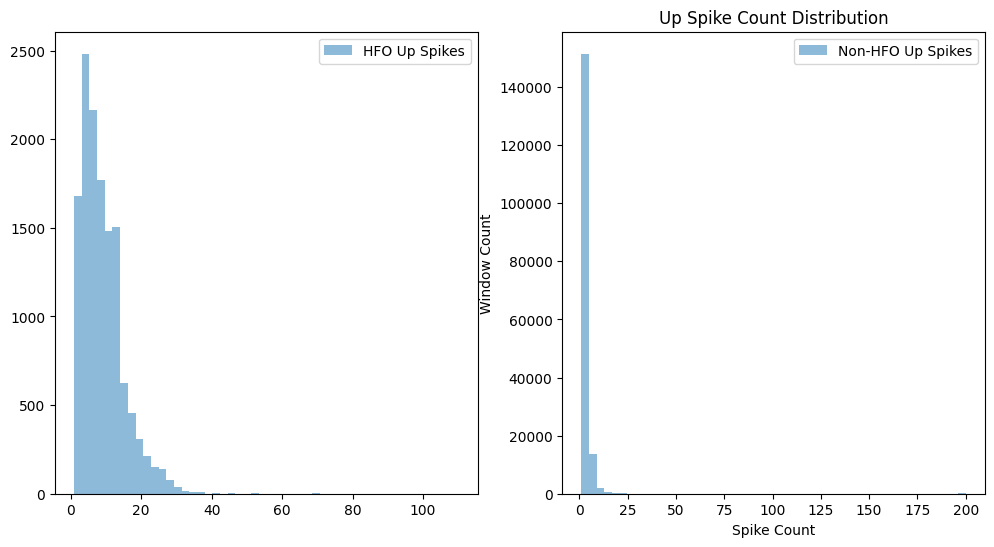

In [32]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(total_hfo_counts,bins=50, alpha=0.5, label='HFO Up Spikes')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Up Spikes')
plt.legend()
plt.title('Up Spike Count Distribution')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.show()

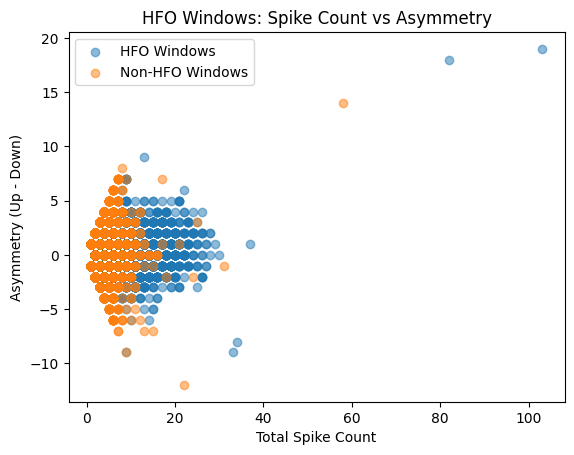

In [42]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(total_hfo_counts,asymmetry_hfos , alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,asymmetry_nonhfos, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

Text(0.5, 1.0, 'HFO Windows: Spike Count vs Asymmetry')

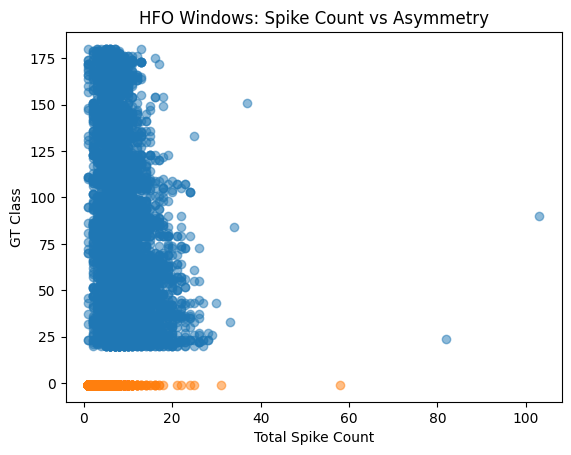

In [43]:
plt.scatter(total_hfo_counts,windowed_gt_hfo, alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs Asymmetry')

## After Undersampling Non-Ripples

In [44]:
from snnTorch.utils.training import undersample_majority, oversample_minority
intermediate_input, intermediate_gt = windowed_input_data, windowed_gt  # Default: No Balancing
balance=True
if balance:
    intermediate_input, intermediate_gt = undersample_majority(windowed_input_data, windowed_gt)
    # intermediate_input, intermediate_gt = undersample_majority(p2_windowed_input_data, p2_windowed_gt)  

# Print the number of samples in each class
print(f"Intermediate GT Class Distribution: {np.unique(intermediate_gt, return_counts=True)}")
print(f"Intermediate Window Input Data Shape: {intermediate_input.shape}")


Intermediate GT Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 161., 162., 163., 164., 165., 166., 167., 168., 169.,
       170., 171., 172., 173., 174., 175., 176., 177., 178., 179., 180.], dtype=float32), array([10648,   134,    78,   171,   209,    89,    88,   141,   112,    79,    55,    82,   103,
         194,   141,    52,   108,   150,   150,    21, ...,    22,    23,    38,    68,    74,
          52,    37,    81,     7,    53,    28,    28,    15,    55,    15,    31,    38,    53,
          30,    37], dtype=int64))
Intermediate Window Input Data Shape: (21296, 200, 2)


In [45]:
is_hfo= intermediate_gt >= 0
hfo_windows = intermediate_input[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = intermediate_input[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = intermediate_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = intermediate_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2)
print(f"Number of HFO windows: {hfo_windows.shape[0]}")
print(f"Number of Non-HFO windows: {non_hfo_windows.shape[0]}")

Number of HFO windows: 10648
Number of Non-HFO windows: 10648


In [ ]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts

average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(total_nonhfo_counts)
average_total_counts= (np.sum(total_hfo_counts)+np.sum(total_nonhfo_counts))/len(intermediate_input)

print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")

# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])


In [ ]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(total_hfo_counts,bins=50, alpha=0.5, label='HFO Up Spikes')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Up Spikes')
plt.legend()
plt.title('Up Spike Count Distribution')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.show()

In [ ]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(hfo_up_isi_mean, bins=50, alpha=0.5, label='HFO ISI (Up)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(nonhfo_up_isi_mean, bins=50, alpha=0.5, label='Non-HFO ISI (Up)')
plt.legend()
plt.suptitle('Mean Inter-Spike Interval per Window')
plt.xlabel('ISI')
plt.ylabel('Window Count')
plt.show()

In [ ]:
plt.subplots(figsize=(12, 6))
plt.hist(windowed_gt_hfo, bins=50, alpha=0.5, label='HFO GT')
plt.legend()
plt.title('Distribution of HFO GT Classes')
plt.xlabel('Ground Truth Class')
plt.ylabel('Window Count')
plt.show()

In [ ]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(total_hfo_counts,asymmetry_hfos , alpha=0.2, label='HFO Windows')
plt.scatter(total_nonhfo_counts,asymmetry_nonhfos, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

In [ ]:
plt.scatter(total_hfo_counts,windowed_gt_hfo, alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs GT Class')

In [22]:
def make_serializable(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()  # Convert to native Python int or float
    elif isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert arrays to lists
    elif isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    else:
        return obj

In [64]:
# Save the windowed 
# input data and ground truth to a file
save=True
if save:
    windowed_save=os.path.join(curr_dir,"windowed_data")
    os.makedirs(windowed_save, exist_ok=True)
    np.save(os.path.join(windowed_save, "filtered_windows.npy"), filtered_windows, allow_pickle=True)
    np.save(os.path.join(windowed_save, "windowed_input_data.npy"), windowed_input_data, allow_pickle=True)
    np.save(os.path.join(windowed_save,"windowed_gt.npy"), windowed_gt, allow_pickle=True)
    np.save(os.path.join(windowed_save,"ripple_ids.npy"), ripple_ids, allow_pickle=True)
    print("Saved") 
    # # Save the configuration to a JSON file
    # with open(os.path.join(windowed_save, "config.json"), 'w') as f:
    #     serializable_config = make_serializable(config)
    #     json.dump(serializable_config, f, indent=4)

Saved
